# Data Pipeline Validation

This notebook validates the data pipeline before model training.

The main goals are to:

- Verify dataset classes and image counts.
- Check image and tensor dimensions.
- Verify the train/validation split.
- Check for data leakage between training and validation sets.
- Confirm that augmentation is applied only to training data.
- Inspect class distribution.

The validation set is used for model selection and tuning, while the test set remains untouched for final evaluation.

In [1]:
from pathlib import Path

import torch
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

In [2]:
DATA_DIR = Path("../data/raw/casting_data/casting_data")

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32
VAL_RATIO = 0.2
SEED = 42

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])


val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [5]:
train_data = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_data = datasets.ImageFolder(
    TRAIN_DIR,
    transform=val_test_transform
)

test_data = datasets.ImageFolder(
    TEST_DIR,
    transform=val_test_transform
)

In [6]:
print("Classes:", train_data.classes)
print("Class mapping:", train_data.class_to_idx)

Classes: ['def_front', 'ok_front']
Class mapping: {'def_front': 0, 'ok_front': 1}


In [7]:
generator = torch.Generator().manual_seed(SEED)

indices = torch.randperm(
    len(train_data),
    generator=generator
).tolist()

val_size = int(len(indices) * VAL_RATIO)

val_indices = indices[:val_size]
train_indices = indices[val_size:]

train_dataset = Subset(train_data, train_indices)
val_dataset = Subset(val_data, val_indices)

In [8]:
print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_data))

Training: 5307
Validation: 1326
Test: 715


In [9]:
train_set = set(train_indices)
val_set = set(val_indices)

print("Train/Validation overlap:", len(train_set & val_set))

Train/Validation overlap: 0


In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [11]:
images, labels = next(iter(train_loader))

print("Image shape:", images.shape)
print("Label shape:", labels.shape)

Image shape: torch.Size([32, 3, 224, 224])
Label shape: torch.Size([32])


In [12]:
print("Min:", images.min().item())
print("Max:", images.max().item())

Min: 0.0
Max: 0.9960784316062927


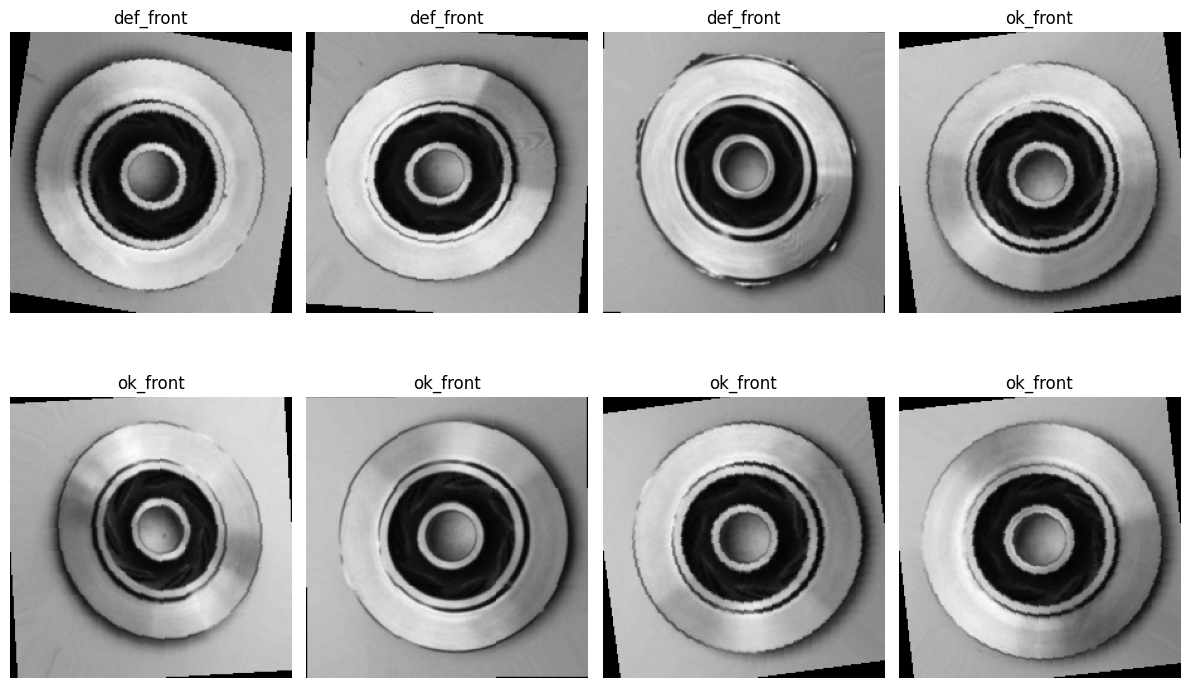

In [13]:
plt.figure(figsize=(12, 8))

for i in range(8):
    image = images[i].permute(1, 2, 0)
    label = labels[i].item()

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(train_data.classes[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

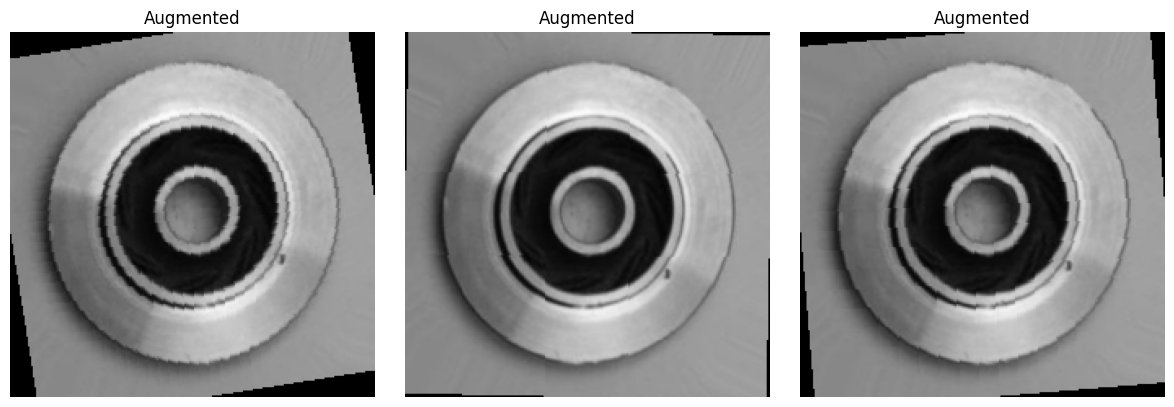

In [14]:
image_path, label = train_data.samples[0]

original_image = datasets.folder.default_loader(image_path)

plt.figure(figsize=(12, 4))

for i in range(3):
    image = train_data[0][0].permute(1, 2, 0)

    plt.subplot(1, 3, i + 1)
    plt.imshow(image)
    plt.title("Augmented")
    plt.axis("off")

plt.tight_layout()
plt.show()

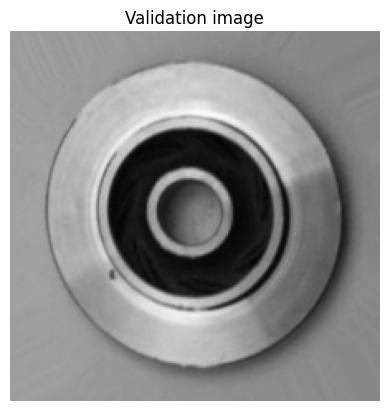

In [15]:
image = val_data[0][0].permute(1, 2, 0)

plt.imshow(image)
plt.title("Validation image")
plt.axis("off")
plt.show()

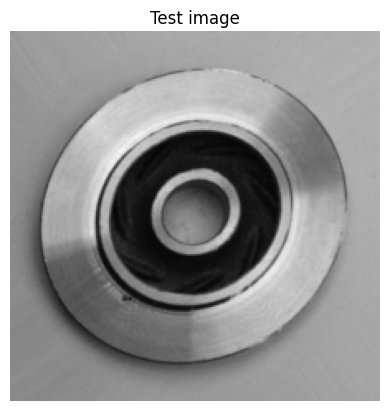

In [16]:
image = test_data[0][0].permute(1, 2, 0)

plt.imshow(image)
plt.title("Test image")
plt.axis("off")
plt.show()

In [17]:
from collections import Counter

train_labels = [train_data.targets[i] for i in train_indices]
val_labels = [val_data.targets[i] for i in val_indices]
test_labels = test_data.targets

print("Train:", Counter(train_labels))
print("Validation:", Counter(val_labels))
print("Test:", Counter(test_labels))

Train: Counter({0: 3015, 1: 2292})
Validation: Counter({0: 743, 1: 583})
Test: Counter({0: 453, 1: 262})


## Conclusion

The data pipeline was successfully validated.

- The dataset contains two classes: `def_front` and `ok_front`.
- The training set is split into training and validation subsets.
- Training images use data augmentation, while validation and test images do not.
- No overlap was found between the training and validation subsets.
- The test set remains isolated for final model evaluation.

The dataset is now ready for the next stage: **feature extraction and model benchmarking**.